In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data_rigid = np.loadtxt("../fullerenes/fullerene_potential.out")
data_relaxed = np.loadtxt("fullerene_distance_scan.out")

/tmp/ipykernel_15892/1701521031.py:24: UserWarning: You passed a edgecolor/edgecolors ('face') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_15892/1701521031.py:36: UserWarning: You passed a edgecolor/edgecolors ('face') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


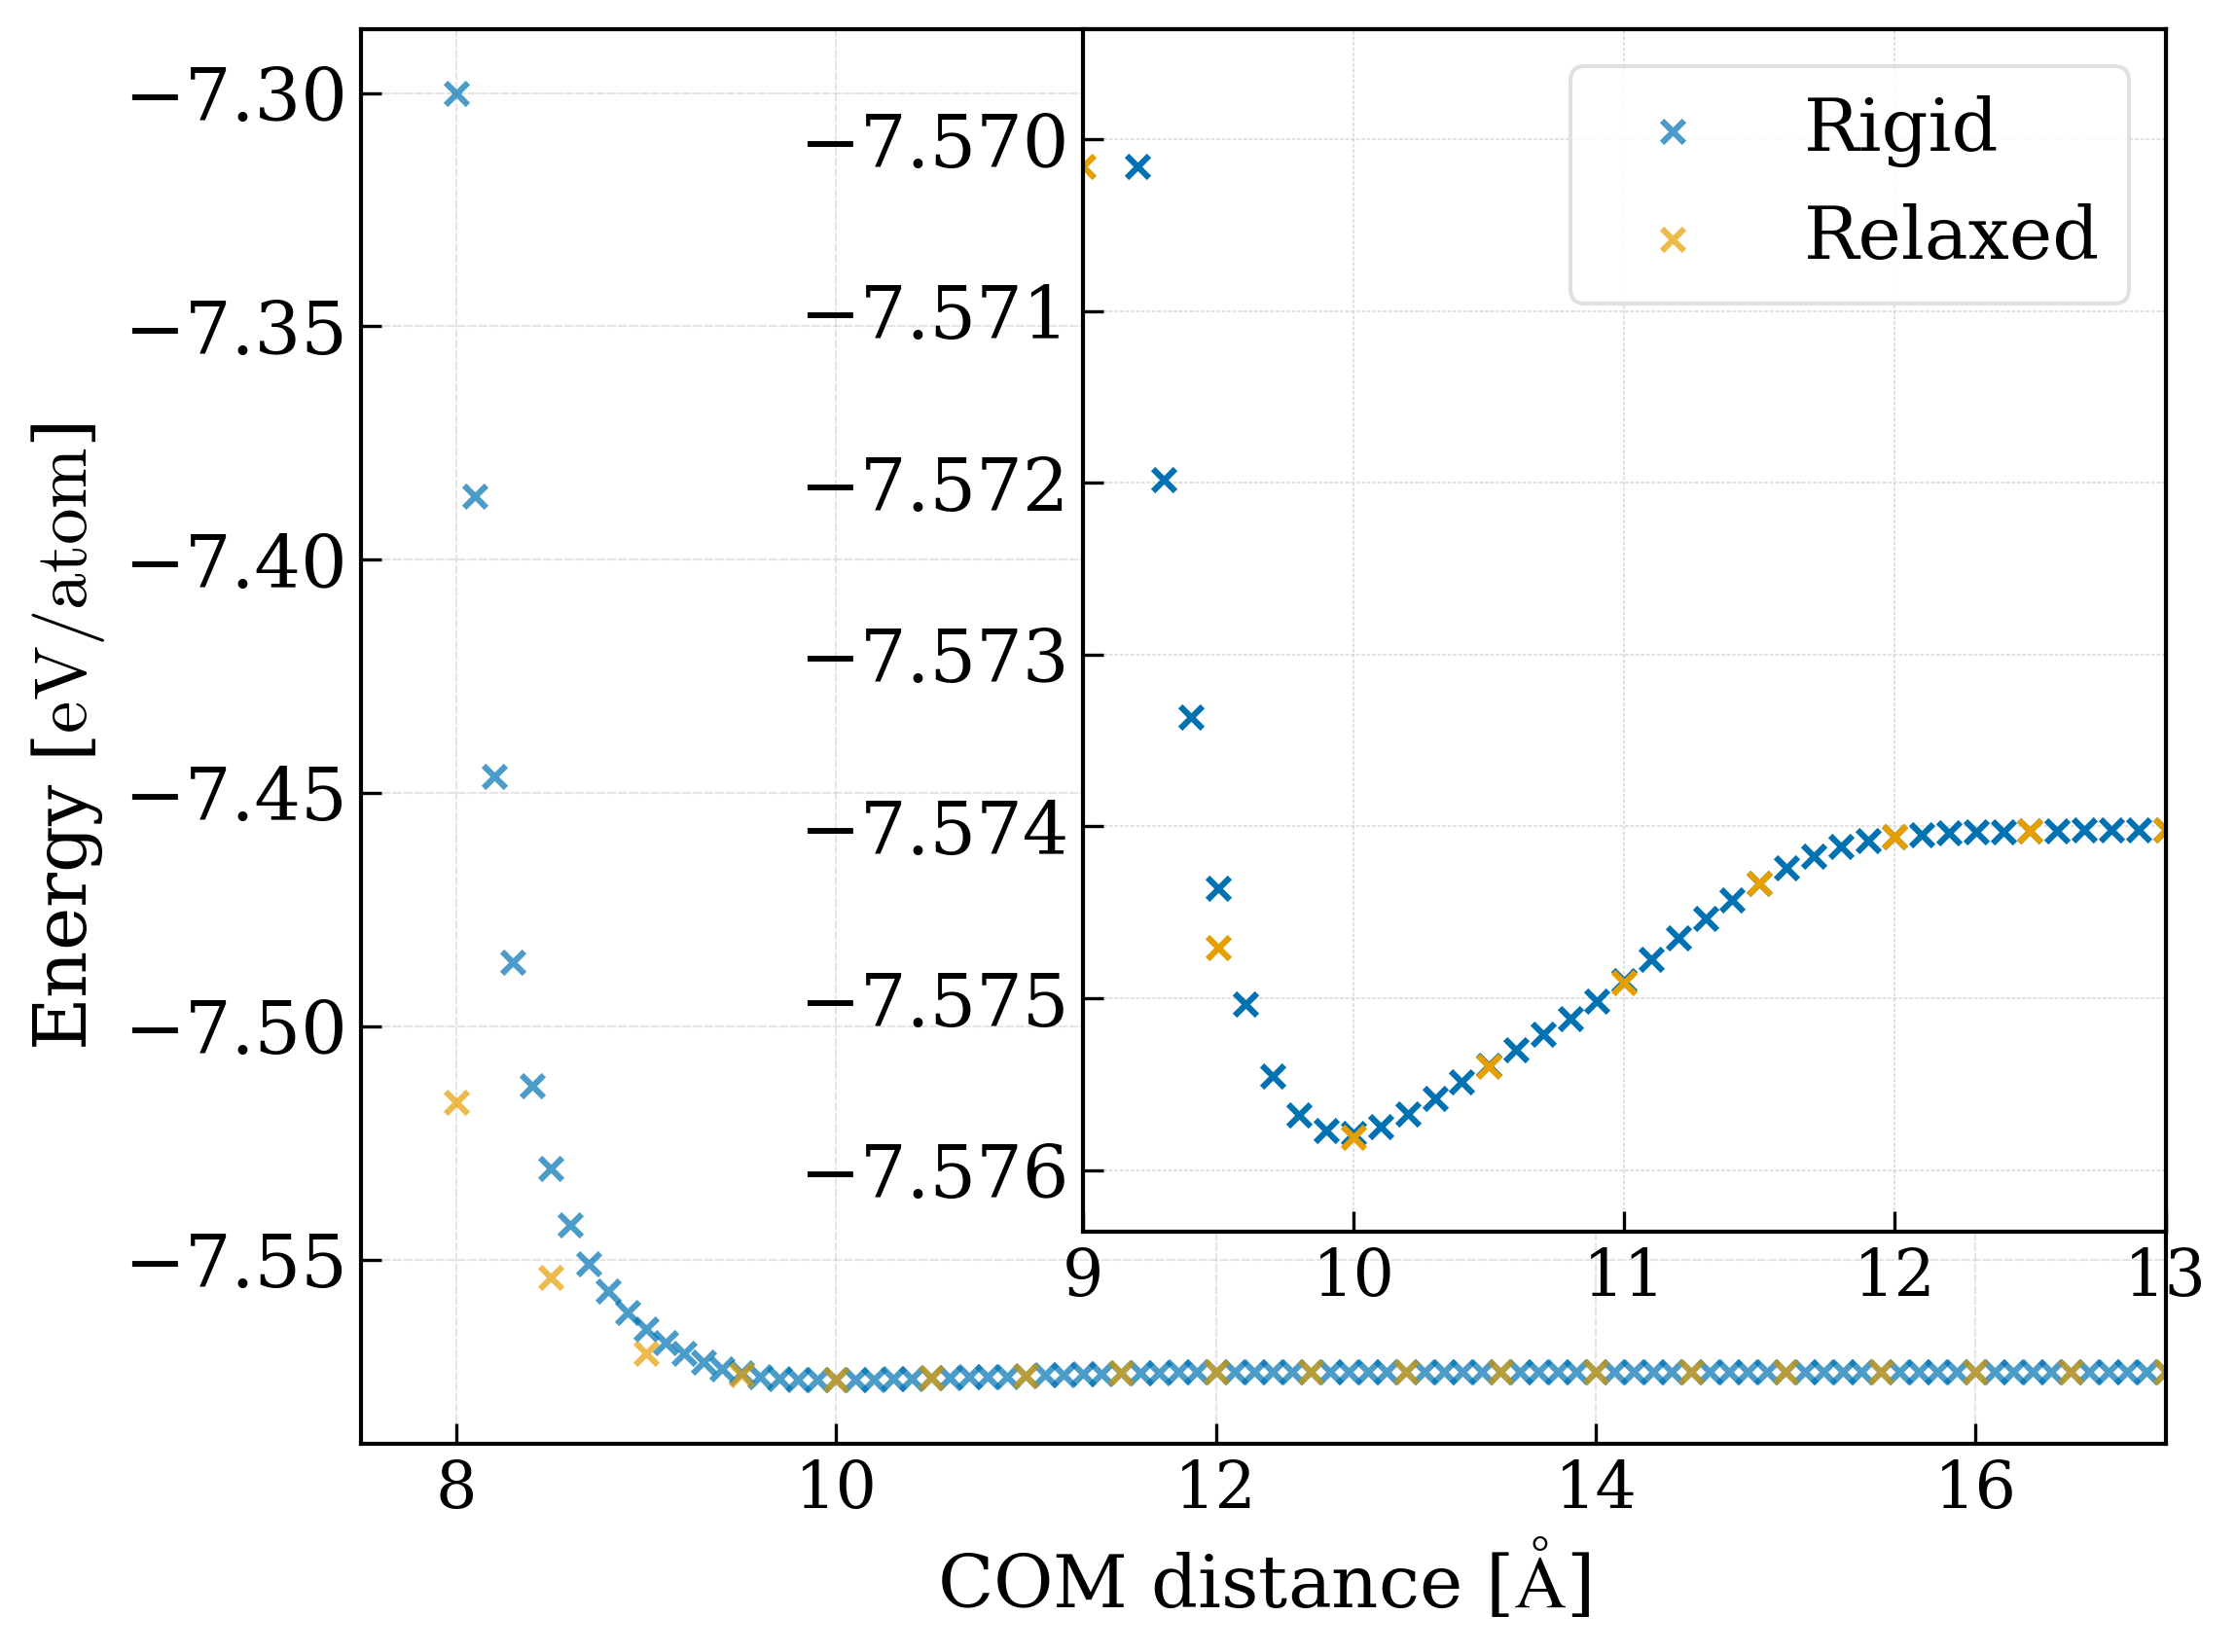

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import polyfit, poly1d

# ==========================================
# 1. SETUP, INITIALIZATION & DATA LOADING
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
scale = 1
num_atoms = 120  # Total atoms (e.g., two C60 fullerenes) to get per-atom energy

# Load the requested datasets
data_rigid = np.loadtxt("../fullerenes/fullerene_potential.out")
data_relaxed = np.loadtxt("fullerene_distance_scan.out")

# Scale axes for plotting consistency
x_rigid = data_rigid[:, 0] * scale
y_rigid = data_rigid[:, 1] / num_atoms

x_relaxed = data_relaxed[:, 0] * scale
y_relaxed = data_relaxed[:, 1] / num_atoms

# Scatter plot for Rigid Data
ax.scatter(
    x_rigid, y_rigid, 
    label="Rigid", 
    alpha=0.7, 
    edgecolors='face', 
    zorder=2,
    rasterized=True,
    s=30,
    marker = "x"
)

# Scatter plot for Relaxed Data
ax.scatter(
    x_relaxed, y_relaxed, 
    label="Relaxed", 
    alpha=0.7, 
    edgecolors='face', 
    zorder=2,
    rasterized=True,
    s=30,
    marker = "x"
)

# ==========================================
# 2. DATA FILTERING & POLYNOMIAL FITTING (RIGID)
# ==========================================
# Clean Inset Limits (defined in scaled units)
# NOTE: Adjust these bounds if the fullerene minimum shifts
quadratic_limits = (9, 13)

# Masking using the scaled rigid X values to target the zoom window
mask = (x_rigid > quadratic_limits[0]) & (x_rigid < quadratic_limits[1])
x_fit_pts = x_rigid[mask]
y_fit_pts = y_rigid[mask]

# Fit 2nd-degree polynomial to the scaled rigid data window
# coeffs order: [a, b, c] for ax^2 + bx + c
coeffs, covar = polyfit(x_fit_pts, y_fit_pts, deg=2, cov=True)
poly2 = poly1d(coeffs)

# ==========================================
# 3. DERIVATIVE & MINIMUM CALCULATIONS WITH UNCERTAINTIES
# ==========================================
a, b, c = coeffs

# Extract variances and covariance from the fit matrix
var_a = covar[0, 0]
var_b = covar[1, 1]
cov_ab = covar[0, 1]

# 1. Minimum Position x_min = -b / (2a)
x_min = -b / (2 * a)
y_min = poly2(x_min)

# Error propagation for x_min
df_da = b / (2 * (a ** 2))
df_db = -1 / (2 * a)
x_min_err = np.sqrt((df_da ** 2) * var_a + (df_db ** 2) * var_b + 2 * df_da * df_db * cov_ab)

# 2. Second-order derivative d^2E/dx^2 = 2a
d2E_dx2_scaled = 2 * a  
d2E_dx2_scaled_err = 2 * np.sqrt(var_a)

# ==========================================
# 4. MAIN PLOT ADDITIONS
# ==========================================
# Generate a wider X range for the main plot parabola
x_wide = np.linspace(9, 12, 200)

# fit_label = (
#     "Rigid Quadratic Fit\n"
#     rf"  Min Position: ${x_min:.4f} \pm {x_min_err:.4f}\ \mathrm{{\AA}}$\n"
#     rf"  Second-order derivative: ${d2E_dx2_scaled:.3f} \pm {d2E_dx2_scaled_err:.3f}\ \mathrm{{eV/\AA^2 atom}}$"
# )
# Set zorder=1 so the fit line passes underneath the data points
# ax.plot(x_wide, poly2(x_wide), color="#ff7f0e", linestyle="--", linewidth=2, label=fit_label, zorder=1)

# ==========================================
# 5. INSET SETUP & ZOOM
# ==========================================
axins = ax.inset_axes([0.4, 0.15, 0.6, 0.85]) 

# Inset scatter for Rigid Data
axins.scatter(
    x_rigid, y_rigid, 
    zorder=2,
    rasterized=True,
    marker = "x",
    s=30
)

# Inset scatter for Relaxed Data
axins.scatter(
    x_relaxed, y_relaxed, 
    zorder=2,
    rasterized=True,
    marker  ="x",
    s=30
)

# Plot the fitted parabola segment tightly inside the inset
x_ins_fit = np.linspace(quadratic_limits[0], quadratic_limits[1], 100)
# axins.plot(x_ins_fit, poly2(x_ins_fit), color="#ff7f0e", linewidth=2.5, zorder=1)

# Set bounds on the inset to look directly at the valley minimum
axins.set_xlim(quadratic_limits) 
# Dynamically center y-limits around the fitted minimum energy point
axins.set_ylim(y_min - 0.001, y_min + 0.006) 
axins.grid(True, linestyle=":", alpha=0.6)

# Optional: Draw the connector lines from the main plot box to the inset axes
# ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.5)

# ==========================================
# 6. GLOBAL FORMATTING & EXPORT
# ==========================================
ax.set_xlabel(r"COM distance [$\mathrm{\AA}$]")
ax.set_ylabel(r"Energy [$\mathrm{eV/atom}$]")
xmin, xmax = 7.5, 17
ax.set_xlim(xmin, xmax)

plt.legend(loc="upper right", framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("BM_fullerene_distance_scan.pdf", bbox_inches="tight")